*Do not delete this style setting*

In [1]:
%%html
<style>
table {float:left}
</style>

# Session 3<br> A Simple Classical Classifier

<table>
    <tr><td><strong>Aim:</strong></td>
        <td>To create a simple classical classifier in <strong>PyTorch</strong><br>
            and compare its workings with the equivalent quantum classifier.</td></tr>
    <tr><td><strong>Author:</strong></td>
        <td>Jacob L. Cybulski (<a href="https://jacobcybulski.com/" target="_blank">website</a>),
            <em>Enquanted</em></td></tr>
    <tr><td><strong>Release:</strong></td>
        <td>April 2025</td></tr>
    <tr><td><strong>Updated:</strong></td>
        <td>April 2026</td></tr>
    <tr><td><strong>Datasets:</strong></td>
        <td>We will use the following two datasets from UCI repository (require: pip install ucimlrepo):<br>
            <ol><li><a href="https://archive.ics.uci.edu/dataset/10/automobile" target="_blank">Automobiles</a>:
              This is a database of automobile specs. The aim is to determine its insurance risk (symboling). Data loading and preprocessing was included below.
              <font color="red">Note: As the website seems temporarily offline, the dataset has been made available for local access in "../data/Automobile.csv".</font></li>
            <li><a href="https://archive.ics.uci.edu/dataset/151/connectionist+bench+sonar+mines+vs+rocks" target="_blank">Sonar</a>:
              The aim is to discriminate between sonar signals bounced off a mine (metal cylinder) or a rock (roughly cylindrical).</li>
            </ol></td></tr>
    <tr><td><strong>Tasks:</strong></td>
        <td>40 minutes (unfinished tasks go to self-directed "challenges")</td></tr>
    <tr>
        <td></td>
        <td>Perform the following tasks<br>(not applicable to this "classical" notebook):<br>
        <ol>
            <li>Initially use the <strong><em>Automobiles</em></strong> dataset 1 (as provided).<br>
                Follow the instructor demonstration to step through the code.<br>
                - we will first look at a classical PyTorch model<br>
                - and then look at the quantum PyTorch+PennyLane model.</li>
            <li>Explore your dataset and think of its impact on the process and results:<br>
                - hint: consider data ordering and what needs to be done about it</li>
            <li>Can you improve the model performance by changing the approach<br>to dimensionality reduction:<br>
                - feature selection based on intuition (default) ?<br>
                - feature selection based on Chi2 ?<br>
                - dimensionality reduction based on PCA ?<br>
                Which of these approaches had the greatest impact on performance?</li>
            <li>Improve the model performance.<br>
                - changes may apply to data, model and its training<br>
                - what methods have you applied and with what result ?</li>
            <li>Create some data on the fantasy automobiles and use the developed model for<br>
                their classification. Does it match your expectation?</li>
            <li>Compare the classical vs quantum classification models and their performance.</li>
            <li>Reflect on this session.</li>
        </ol></td>
    </tr>
    <tr>
        <td><strong>Challenge<br>Tasks:</strong></td>
        <td>Perform one or more of the following tasks in your own time:<br/>
        <ol style="list-style-type: upper-alpha;">
            <li>Complete the unfinished tasks.</li>
            <li>Incorporate custom initialisation of your model (research).</li>
            <li>Change the quantum model by incorporating a full-reuploading ansatz.</li>
            <li>Include the quantum model definition as part of the <strong><em>Quantum_Auto</em></strong> class.</li>
            <li>Change (back) the label variable from binary to multiclass (hard), <br>
                to implement and test a multinomial classification model (research).</li>
            <li>Apply your completed model to the <strong><em>Sonar</em></strong> data set 2</li>
        </ol></td>
    </tr>
    <tr><td><strong>References:</strong></td>
        <td><ul>
            <li><a href = "https://www.youtube.com/watch?v=OIenNRt2bjg" target="_blank">
                AssemblyAI, “PyTorch Crash Course - Getting Started with Deep Learning”,<br>YouTube Video, Jul 2022.</a></li>
            <li><a href = "https://pennylane.ai/qml/demos/tutorial_qnn_module_torch" target="_blank">Thomas Bromley, "Turning quantum nodes into Torch Layers",<br>
                PennyLane Demo, October 7, 2024.</a></li>
            <li><a href = "https://docs.pennylane.ai/en/stable/code/api/pennylane.qnn.TorchLayer.html" target="_blank">PennyLane, "qml.qnn.TorchLayer",<br>
                PennyLane Documentation, Code API, 2025.</a></li>
            <li><a href = "https://pennylane.ai/qml/demos/tutorial_local_cost_functions" target="_blank">Thomas Storwick, "Alleviating barren plateaus with local cost functions",<br>
                PennyLane Tutorial, November 6, 2024.</a></li>
        </ul></td>
    </tr>
    <tr><td><strong>License:</strong></td>
        <td>This project is licensed under the
            <a href="https://www.gnu.org/licenses/gpl-3.0.en.html" target="_blank">GNU General Public License v3</a></td></tr>
    <tr><td><strong>Changes:</strong></td>
        <td>All significant changes to this code must be recorded in this notebook</td></tr>
</table>

## Libraries

In [2]:
import sys
sys.path.append('.')
sys.path.append('..')
sys.path

['/home/jacob/miniconda3/lib/python311.zip',
 '/home/jacob/miniconda3/lib/python3.11',
 '/home/jacob/miniconda3/lib/python3.11/lib-dynload',
 '',
 '/home/jacob/venv/pl/lib/python3.11/site-packages',
 '.',
 '..']

In [3]:
### General libraries

import os
import pylab
import math
import time
import copy
import pandas as pd
from IPython.display import clear_output

import matplotlib.pyplot as plt
from matplotlib import set_loglevel
set_loglevel("warning")

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [4]:
### Import utilities
from utilities import multi_plot_hist, multi_plot_series, draw_circuit

In [5]:
### Import PennyLane and Torch
import pennylane as qml
from pennylane import numpy as np
from pennylane import NesterovMomentumOptimizer
from torch import nn
from torch.autograd import Variable
import torch

---

## <font color="blue">Data preparation</font>

Selected dataset: <a href="https://archive.ics.uci.edu/dataset/10/automobile" target="_blank">Automobiles</a>.
  
<font color="CornflowerBlue">_**Data needs to be prepared as follows:**_</font>

- <font color="CornflowerBlue">*Load and understand data*</font>
- <font color="CornflowerBlue">*Select numerical variables only (make it simple)*</font>
- <font color="CornflowerBlue">*Eliminate missing values*</font>
- <font color="CornflowerBlue">*Prepare the label (change it to binary)*</font>
- <font color="CornflowerBlue">*Standardise predictors*</font>
- <font color="CornflowerBlue">*Reduce dimensionality*</font>

In [6]:
### Dataset settings
n_features = 5
data_seed = 42

### Load and understand data
*The original source of data included for reference.*

In [7]:
# from ucimlrepo import fetch_ucirepo

# auto = fetch_ucirepo(id=10)
# X_vars = auto.data.features 
# y_class = auto.data.targets 
# print(auto.metadata['additional_info']['summary'],'\n') 

In [8]:
import pandas as pd

### Fetch data from the local repository
filepath = '../data/Automobile.csv'
headers = ['symboling','normalized-losses','make','fuel-type','aspiration', 'num-of-doors','body-style',
           'drive-wheels','engine-location','wheel-base', 'length','width','height','curb-weight','engine-type',
           'num-of-cylinders', 'engine-size','fuel-system','bore','stroke','compression-ratio','horsepower',
           'peak-rpm','city-mpg','highway-mpg','price']

automobile = pd.read_csv(filepath, sep='#', decimal='.', header=None, names=headers)

### Split data frame into X and y vectors
y_class = automobile[['symboling']]
X_vars = automobile.drop(columns=['symboling'])

In [9]:
X_vars.head(5)

,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### Preliminary data processing

In [10]:
### After a brief investigation, it is evident that ...
#   this data set has a serious problem and cannot be used as it is!
...

Ellipsis

### Select numerical predictors only

In [11]:
### Select numeric columns only
X_sel = X_vars.select_dtypes(include=np.number)
X_sel.columns

Index(['normalized-losses', 'wheel-base', 'length', 'width', 'height',
       'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio',
       'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'],
      dtype='object')

### Deal with missing values

In [12]:
### Identify columns with missing values
X_sel.isna().sum().loc[lambda x : x > 0].sort_index()

bore                  4
horsepower            2
normalized-losses    47
peak-rpm              2
price                 4
stroke                4
dtype: int64

In [13]:
### Replace missing values with column mean
#   Then check that missing values have been eliminated
auto_xmean = X_sel.mean()
X_sel = X_sel.fillna(auto_xmean)
X_sel.isna().sum().loc[lambda x : x > 0]

Series([], dtype: int64)

### Standardise predictors

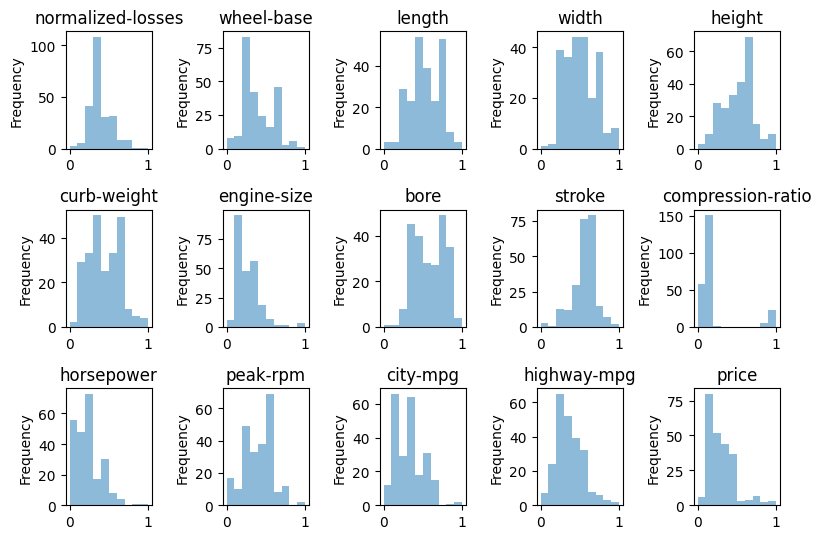

In [14]:
# Standardise all variables
from sklearn.preprocessing import StandardScaler, MinMaxScaler
auto_scaler = MinMaxScaler(feature_range=(0, 1)) 
scaled = auto_scaler.fit_transform(X_sel) 
X_std = pd.DataFrame(scaled, columns=X_sel.columns)
multi_plot_hist(X_std, n_cols = 5, figsize=(8,5.5));

### Prepare the label
<font color="CornflowerBlue">As the label is numeric and multi-class, to simplify the task we turn the label into a binary variable.<br>
The binary class split will be around the distribution mean.</font>

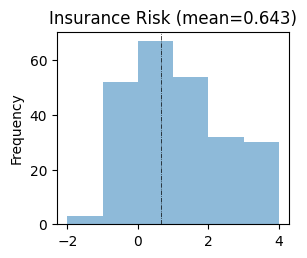

In [15]:
### Observe label distribution
auto_ymean = y_class["symboling"].mean()
ax = y_class.plot.hist(bins=6, alpha=0.5, title=f'Insurance Risk (mean={round(auto_ymean, 3)})', 
                       figsize=(3,2.5))
ax.get_legend().remove()
plt.axvline(auto_ymean, color='k', linestyle='-.', linewidth=0.5);

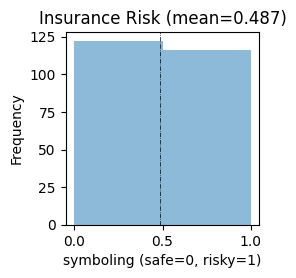

In [16]:
### Create a binary label
pd.set_option('display.max_rows', 10)
y_std = pd.DataFrame(y_class)
y_std['symboling'] = np.where(y_std['symboling'] > auto_ymean, 1, 0)
y_binmean = y_std["symboling"].mean()

ax = y_std.plot.hist(bins=2, alpha=0.5, title=f'Insurance Risk (mean={np.round(y_binmean, 3)})', 
                 figsize=(2.5,2.5))
ax.set_xlabel(f'{y_std.columns[0]} (safe=0, risky=1)')
ax.get_legend().remove()
plt.axvline(y_binmean, color='k', linestyle='-.', linewidth=0.5);

### Reduce data dimensionality
Note that we should somehow reduce data dimensionality.

In [17]:
### The number of features to select
col_names = list(X_std.columns)
print(f'\nNumber of features available: {X_std.shape[1]}\n'+\
      f'Number of features to select: {n_features}\n\n'+\
      f'Features: {*col_names,}')


Number of features available: 15
Number of features to select: 5

Features: ('normalized-losses', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price')


#### Feature selection based on intuition

In [18]:
X_hunch = X_std[['price', 'highway-mpg', 'city-mpg', 'peak-rpm', 'horsepower']]
X_hunch.columns

Index(['price', 'highway-mpg', 'city-mpg', 'peak-rpm', 'horsepower'], dtype='object')

#### Feature selection based on statistical analysis (ANOVA F-test or $\chi^2$)

In [19]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif

# Feature extraction
selector = SelectKBest(score_func=f_classif, k=n_features)
X_ext = selector.fit_transform(X_std, y_std)

# Identify selected features
columns_mask = selector.get_support()
sel_features = X_std.columns[columns_mask]
X_kbest = pd.DataFrame(data = X_ext, columns = sel_features)
X_kbest.columns

Index(['wheel-base', 'length', 'width', 'height', 'curb-weight'], dtype='object')

#### Dimensionality reduction with PCA

In [20]:
from sklearn.decomposition import PCA

n_components = n_features
auto_pca = PCA(n_components=n_components)
X_pca = auto_pca.fit_transform(X_std)
X_pca = pd.DataFrame(X_pca, columns=[f'PC{n:02d}' for n in range(X_pca.shape[1])])
pca_var = auto_pca.explained_variance_ratio_
print(f'Explained var = {np.sum(pca_var):02.3f}')
X_pca.columns

Explained var = 0.863


Index(['PC00', 'PC01', 'PC02', 'PC03', 'PC04'], dtype='object')

#### Select an approach to dimensionality reduction
<font color="CornflowerBlue">Select the method of dimensionality reduction by copying the required version of X.<br>
All versions have been defined above.</font>

In [21]:
X = X_hunch.copy()
y = y_std.copy()

***

## <font color="blue">Model development</font>

### Utilities

In [22]:
### Performance measures

### A simple MSE cost function
def square_mse(labels, predictions):
    sq_diffs = torch.tensor([(l - p)**2 for l, p in zip(labels, predictions)])
    return sq_diffs.mean().item()

### Calculates accuracy from expval predictions
def accuracy(labels, predictions, prec=1e-5):
    acc = sum(abs(l - p) < prec for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc.item()

### Counts the number of pytorch model parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Define device to compute on

In [23]:
### Find what devices are available

# Enable CUDA device if available
torch_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f'\nThe available devices:\t\t{torch_device}')

# Force CPU to avoid moving computation and data back and from the GPU
torch_device = "cpu"

print(f'PyTorch device to be used:\t{torch_device}\n')


The available devices:		cuda:0
PyTorch device to be used:	cpu



### Model and training configuration

In [24]:
### Data params
n_data = X.shape[0]
x_angle_margin = 0.1
x_angle_min = 0+x_angle_margin
x_angle_max = np.pi-x_angle_margin

### Training params
epochs = 400     # 50 # 80 # 100 # 300
log_interv = 1   # History to be saved only once every interv or epochs
acc_prec = 0.5   # Precision of accuracy calculation
shots = None     # None means using theoretical frequency distribution 
seed = 2025

### Prepare data exactly as for the quantum classifier

<font color="CornflowerBlue">Note that we have already scaled the X values to the [0..1] range.<br>
That value range was needed to perform PCA, if this dimensionality reduction was to be used.<br>
We could not scale X to the range of values [0..pi] as required for quantum data encoding,<br>
as PCA would have changed that range later on.</font>

In [25]:
### Standardise X values to the range 0+margin..pi-margin
from sklearn.preprocessing import StandardScaler, MinMaxScaler
angle_scaler = MinMaxScaler(feature_range=(x_angle_min, x_angle_max)) 
scaled = angle_scaler.fit_transform(X) 
X = pd.DataFrame(scaled, columns=X.columns)

In [26]:
### Create data partitions
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X.iloc[:,0:n_data], y.iloc[:,0:n_data], 
    test_size=0.33, shuffle=False, random_state=seed)
print(f'Shapes: X_train={X_train.shape}, X_test={X_test.shape}, y_train={y_train.shape}, y_test={y_test.shape}')

Shapes: X_train=(159, 5), X_test=(79, 5), y_train=(159, 1), y_test=(79, 1)


In [27]:
### Change the data format to tensors
X_train_tens = torch.tensor(np.array(X_train), dtype=torch.double)
y_train_tens = torch.tensor(np.array(y_train), dtype=torch.double)
X_test_tens  = torch.tensor(np.array(X_test), dtype=torch.double)
y_test_tens  = torch.tensor(np.array(y_test), dtype=torch.double)

### PyTorch model with PennyLane layer

<font color="CornflowerBlue">To use PennyLane Torch layers refer to the 
<a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnn.TorchLayer.html" target="_blank">TorchLayer PennyLane API</a>
as well as <a href = "https://pennylane.ai/qml/demos/tutorial_qnn_module_torch" target="_blank">Thomas Bromley tute on Torch layers</a>.</font>

In [28]:
### Classic classifier
class Classic_Auto(nn.Module):

    def __init__(self, in_shape, out_shape):
        super(Classic_Auto, self).__init__()

        # self.model = nn.Sequential(
        #     nn.Linear(in_shape, 32),
        #     nn.ReLU(),
        #     nn.Linear(32, 64),
        #     nn.ReLU(),
        #     nn.Linear(64, 32),
        #     nn.ReLU(),
        #     nn.Linear(32, 8),
        #     nn.ReLU(),
        #     nn.Linear(8, out_shape)
        # )
        
        layers = self.layers(in_shape, out_shape)
        self.model = nn.Sequential(*layers)
        
    def layers(self, in_shape, out_shape):
        
        clayer_0 = torch.nn.Linear(in_shape, 32)
        clayer_1 = torch.nn.ReLU()
        clayer_2 = torch.nn.Linear(32, 64)
        clayer_3 = torch.nn.ReLU()
        clayer_4 = torch.nn.Linear(64, 32)
        clayer_5 = torch.nn.ReLU()
        clayer_6 = torch.nn.Linear(32, 8)
        clayer_7 = torch.nn.ReLU()
        clayer_8 = torch.nn.Linear(8, out_shape)
        
        layers = [clayer_0, clayer_1, clayer_2, clayer_3, clayer_4,
                  clayer_5, clayer_6, clayer_7, clayer_8]
        return layers

    def forward(self, x):
        x = self.model(x)
        return x

### Test the classical PyTorch model before use

In [29]:
### Create a test model and draw the test model circuit
test = Classic_Auto(in_shape=X_train_tens.shape[1], out_shape=y_train_tens.shape[1]).double().to(torch_device)

print(f'\nCM weights: {count_params(test)}, Epochs: {epochs}')
print(f'\nTest results: {test(X_train_tens[0:5])}\n')
test.eval()


CM weights: 4657, Epochs: 400

Test results: tensor([[0.2916],
        [0.2902],
        [0.3073],
        [0.2809],
        [0.2929]], dtype=torch.float64, grad_fn=<AddmmBackward0>)



Classic_Auto(
  (model): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=8, bias=True)
    (7): ReLU()
    (8): Linear(in_features=8, out_features=1, bias=True)
  )
)

### Creation and training of the PennyLane/PyTorch model

In [30]:
### Trains a PyTorch model (of any kind)

def train_model(model, X, y, cost_fun, acc_fun, optimizer, epochs, 
                    log_interv=100, prompt_fract=0.1, acc_prec=0.5, start_time=0):
    
    history = []
    acc_hist = []
    opt_params = {}
    hist_params = []
    min_epoch = 0
    min_cost = 1000
    max_acc = -1000
    if start_time == 0: start_time = time.time()
    
    model.train()
    for epoch in range(epochs):
        
        optimizer.zero_grad()
        output = model(X)
        cost = cost_fun(output, y)
        acc = acc_fun(output, y, prec=acc_prec)
        cost.backward()
        optimizer.step()

        curr_cost = cost.item()
        curr_acc = acc
        if curr_cost < min_cost: 
            min_cost = curr_cost
            min_epoch = epoch
            opt_params = copy.deepcopy(model.state_dict())

        if curr_acc > max_acc:
            max_acc = curr_acc

        if epoch % log_interv == 0:
            history.append(curr_cost)
            acc_hist.append(curr_acc)
            hist_params.append(copy.deepcopy(model.state_dict()))

        elapsed = time.time() - start_time
        if (prompt_fract == 0) or (epoch % int(prompt_fract*epochs) == 0):
            print(f'{epoch: 5d} '+ \
                  f'({elapsed:06.0f} sec): '+ \
                  f'Cost {curr_cost:6.4g}   '+ \
                  f'Acc {curr_acc:6.4g}')
            
    return history, acc_hist, opt_params, hist_params, (min_epoch, min_cost)

### Training loop

In [31]:
### Ensure repeatability
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Create a model
q_auto = Classic_Auto(in_shape=X_train_tens.shape[1], out_shape=y_train_tens.shape[1]).double().to(torch_device)

### Loss and optimiser
cost_fun = nn.MSELoss()

# opt = optim.SGD(model.parameters(),lr=0.01,weight_decay=1e-5)
# opt = torch.optim.Adam(q_auto.parameters())
opt = torch.optim.NAdam(q_auto.parameters(), lr=0.01)

### Train the model
print()

prompt_fract = 0.1
start_time = time.time()
train_mse_hist, train_acc_hist, opt_params, hist_params, opt_point = \
    train_model(q_auto, X_train_tens, y_train_tens, cost_fun, accuracy, opt, epochs, 
                log_interv=log_interv, prompt_fract=prompt_fract, acc_prec=acc_prec)
elapsed = time.time() - start_time

### Print the training summary
train_min_mse = np.min(train_mse_hist)
train_min_mse_iter = np.argmin(train_mse_hist)
train_max_acc = np.max(train_acc_hist)
train_max_acc_iter = np.argmax(train_acc_hist)

time_str = time.strftime("%H:%M:%S", time.gmtime(elapsed))
print(f'\nTraining completed: epochs={epochs} '+\
      f'in {elapsed:0.0f}sec ({time_str})\n\t'+
      f'min MSE = {np.round(train_min_mse, 5):05.4f} @ {train_min_mse_iter:04d}, '+
      f'max ACC = {np.round(train_max_acc, 5):05.4f} @ {train_max_acc_iter:04d}')


    0 (000000 sec): Cost 0.4598   Acc 0.4214
   40 (000000 sec): Cost  0.178   Acc 0.7925
   80 (000000 sec): Cost 0.1659   Acc 0.7673
  120 (000001 sec): Cost 0.1403   Acc 0.8176
  160 (000001 sec): Cost 0.1307   Acc 0.8302
  200 (000001 sec): Cost 0.1441   Acc 0.8365
  240 (000001 sec): Cost 0.09786   Acc 0.8616
  280 (000001 sec): Cost 0.09293   Acc 0.8805
  320 (000001 sec): Cost 0.07795   Acc 0.8805
  360 (000001 sec): Cost 0.09344   Acc 0.8679

Training completed: epochs=400 in 2sec (00:00:01)
	min MSE = 0.0647 @ 0391, max ACC = 0.9120 @ 0340


### Calculate testing scores

In [32]:
### Accumulate test scores
test_mse_hist = []
test_acc_hist = []

### Initialise testing loss and accuracy
test_min_mse = 1000
test_min_mse_iter = -1
test_max_acc = 0
test_max_acc_iter = -1

### Calculate testing loss and accuracy
print()
for iter in range(len(hist_params)):
    q_auto.load_state_dict(hist_params[iter])
    test_pred = q_auto(X_test_tens)
    curr_acc = accuracy(y_test_tens, test_pred, prec=acc_prec)
    curr_cost = square_mse(y_test_tens, test_pred)
    test_acc_hist.append(curr_acc)
    test_mse_hist.append(curr_cost)
    if curr_acc > test_max_acc:
        test_max_acc = curr_acc
        test_max_acc_iter = iter
    if curr_cost < test_min_mse:
        test_min_mse = curr_cost
        test_min_mse_iter = iter
    if (prompt_fract == 0) or (iter % int(prompt_fract*epochs) == 0):
        print(f'Iter#: {iter:3d} / {epochs:3d}, '+
              f'Training: MSE = {train_mse_hist[iter]:.6f}, ACC = {train_acc_hist[iter]:.6f}; '+\
              f'Testing:  MSE = {curr_cost:.6f}, ACC = {curr_acc:.6f}')

### Run summary
time_str = time.strftime("%H:%M:%S", time.gmtime(elapsed))
print(f'\nCompleted calculation of testing scores\n\nSummary of model training run\n\n\t'+
      f'params = {count_params(q_auto)}, '+
      f'epochs = {epochs}, '+
      f'time = {elapsed:0.0f}sec ({time_str})\n\t'+
      f'training: MSE = {np.round(train_min_mse, 5):05.4f} @ {train_min_mse_iter:04d}, '+
      f'ACC = {np.round(train_max_acc, 5):05.4f} @ {train_max_acc_iter:04d}\n\t'+
      f'testing:  MSE = {np.round(test_min_mse, 5):05.4f} @ {test_min_mse_iter:04d}, '+
      f'ACC = {np.round(test_max_acc, 5):05.4f} @ {test_max_acc_iter:04d}\n\t'+
      f'\n'
     )


Iter#:   0 / 400, Training: MSE = 0.459820, ACC = 0.421384; Testing:  MSE = 0.229496, ACC = 0.696203
Iter#:  40 / 400, Training: MSE = 0.178014, ACC = 0.792453; Testing:  MSE = 0.310387, ACC = 0.443038
Iter#:  80 / 400, Training: MSE = 0.165931, ACC = 0.767296; Testing:  MSE = 0.290534, ACC = 0.481013
Iter#: 120 / 400, Training: MSE = 0.140271, ACC = 0.817610; Testing:  MSE = 0.341977, ACC = 0.405063
Iter#: 160 / 400, Training: MSE = 0.130729, ACC = 0.830189; Testing:  MSE = 0.353111, ACC = 0.417722
Iter#: 200 / 400, Training: MSE = 0.144087, ACC = 0.836478; Testing:  MSE = 0.497864, ACC = 0.443038
Iter#: 240 / 400, Training: MSE = 0.097863, ACC = 0.861635; Testing:  MSE = 0.506196, ACC = 0.329114
Iter#: 280 / 400, Training: MSE = 0.092935, ACC = 0.880503; Testing:  MSE = 0.474373, ACC = 0.392405
Iter#: 320 / 400, Training: MSE = 0.077954, ACC = 0.880503; Testing:  MSE = 0.680244, ACC = 0.329114
Iter#: 360 / 400, Training: MSE = 0.093436, ACC = 0.867925; Testing:  MSE = 0.506391, ACC 

### Plot costs and scores

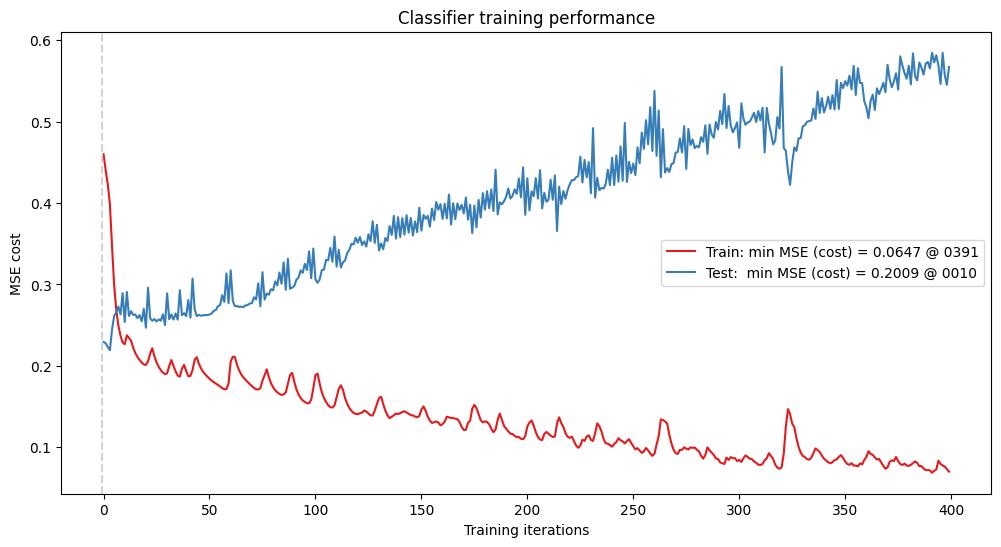

In [33]:
train_label = f'Train: min MSE (cost) = {round(train_min_mse, 5):05.4f} @ {train_min_mse_iter:04d}'
test_label =  f'Test:  min MSE (cost) = {round(test_min_mse, 5):05.4f} @ {test_min_mse_iter:04d}'
multi_plot_series(
    [train_mse_hist, test_mse_hist], X_list=[0, 0], labels=[train_label, test_label], 
    lines=['solid', 'solid'], # colors=None, markers=None, marker_colors=None,
    rcParams=(12, 6), xlabel='Training iterations', ylabel='MSE cost',
    legend_cols=1, smooth_weight=0.6, title='Classifier training performance')

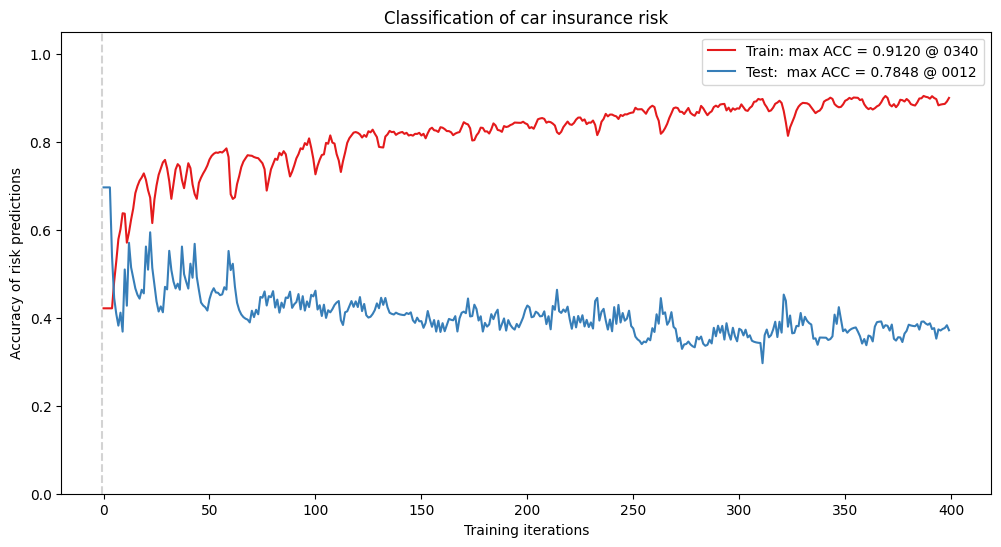

In [34]:
train_label = f'Train: max ACC = {round(train_max_acc, 5):05.4f} @ {train_max_acc_iter:04d}'
test_label =  f'Test:  max ACC = {round(test_max_acc, 5):05.4f} @ {test_max_acc_iter:04d}'
multi_plot_series(
    [train_acc_hist, test_acc_hist], X_list=[0, 0], labels=[train_label, test_label], 
    lines=['solid', 'solid'], ylim=(0, 1.05), # colors=None, markers=None, marker_colors=None,
    rcParams=(12, 6), xlabel='Training iterations', ylabel='Accuracy of risk predictions',
    legend_cols=1, smooth_weight=0.6, title='Classification of car insurance risk')

---

## Write your observations here

- Task 1:
- Task 2:
- Task 3:
- Task 4:
- Task 5:
- Challenge:
- Reflection:

## Modifications (do not remove)
Under the [GPL-3.0](https://www.gnu.org/licenses/gpl-3.0.txt) license, if you perform any changes to this notebook, please list them here, adding a note with your name, contact details, date and changes to the code.

- [Jacob Cybulski](http://jacobcybulski.com) (2025, 1 April): The author of this notebook added this section to record all code changes
- [Jacob Cybulski](http://jacobcybulski.com) (2026, 9 April): Now also compatible with...<br>
  pennylane                 0.44.1<br>
  pennylane_lightning       0.44.0<br>
  torch                     2.11.0+cpu<br>
  torchaudio                2.11.0<br>
  torchvision               0.26.0+cpu<br>

## Software (Linux)

In [35]:
import os
os.system('pip list | grep -e pennylane -e torch');

pennylane                 0.42.3
pennylane_lightning       0.42.0
torch                     2.8.0
torchaudio                2.8.0
torcheval                 0.0.7
torchmetrics              1.8.2
torchsummary              1.5.1
torchvision               0.23.0
